In [1]:
from pathlib import Path
import pandas as pd

ROOT           = Path().resolve().parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

X_train = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
y_train = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (8367, 8)
X_test:  (2092, 8)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred = modelo_lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f'Regresión Logística AUC: {auc:.4f}')

Regresión Logística AUC: 0.7340


In [3]:
import lightgbm as lgb

modelo_lgb = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
modelo_lgb.fit(X_train, y_train)

y_pred_lgb = modelo_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
print(f'LightGBM AUC: {auc_lgb:.4f}')

[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM AUC: 0.7785


In [4]:
import xgboost as xgb
modelo_xgb = xgb.XGBClassifier(scale_pos_weight=1, random_state=42, eval_metric="auc")
modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print(f"XGBoost AUC: {auc_xgb:.4f}")

XGBoost AUC: 0.7655


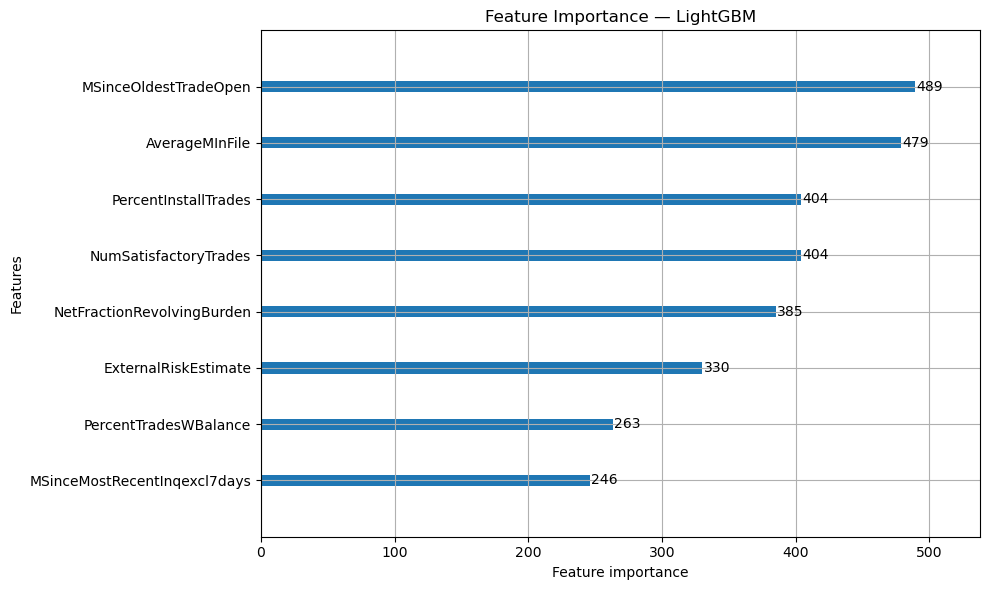

In [5]:
import matplotlib.pyplot as plt

lgb.plot_importance(modelo_lgb, figsize=(10, 6), title='Feature Importance — LightGBM')
plt.tight_layout()
plt.show()

### MLFlow - Rastreo

In [6]:
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Definir experimento
mlflow.set_experiment('credit-risk-heloc')

print('MLflow listo')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

MLflow listo
Tracking URI: sqlite:///C:/Users/sampa/Downloads/credit_risk_ml/notebooks/mlflow.db


In [7]:
import numpy as np

def calcular_metricas(y_test, y_pred_proba):
    auc  = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1

    # KS statistic
    from scipy.stats import ks_2samp
    ks = ks_2samp(y_pred_proba[y_test == 1], y_pred_proba[y_test == 0]).statistic

    return {'auc': round(auc, 4), 'gini': round(gini, 4), 'ks': round(ks, 4)}

print('Métricas definidas')

Métricas definidas


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [9]:
modelos = {
    "LogisticRegression" : LogisticRegression(class_weight = 'balanced', random_state=42, max_iter=1000),
    "RandomForest": RandomForestClassifier(class_weight = 'balanced', random_state=42, n_estimators=100),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="auc"),
    "LightGBM": lgb.LGBMClassifier(class_weight="balanced", random_state=42),
    "LightGBM_FeatureSelection": Pipeline([
        ("selector", SelectKBest(f_classif, k=5)),
        ("model", lgb.LGBMClassifier(class_weight="balanced",  random_state=42))
    ])
}

In [10]:
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=nombre):
        ## entrenar modelos
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict_proba(X_test)[:,1]

        ##metricas
        metricas = calcular_metricas(y_test, y_pred)

        
        ## loggear en mlflow
        mlflow.log_metrics(metricas)
        mlflow.log_param("modelo", nombre)
        print(f'{nombre:35} AUC: {metricas["auc"]}  Gini: {metricas["gini"]}  KS: {metricas["ks"]}')

print('\n Todos los modelos loggeados en MLflow')

LogisticRegression                  AUC: 0.734  Gini: 0.468  KS: 0.3716
RandomForest                        AUC: 0.7765  Gini: 0.5529  KS: 0.4188
XGBoost                             AUC: 0.7655  Gini: 0.5311  KS: 0.4113
[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM                            AUC: 0.7785  Gini: 0.557  KS: 0.4273
[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the

C:\Users\sampa\anaconda3\envs\credit-risk\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
lgb.LGBMClassifier()

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
###pip install optuna

In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 100),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':      trial.suggest_float('reg_lambda', 0.0, 1.0),
        'class_weight':    'balanced',
        'random_state':    42
    }

    modelo = lgb.LGBMClassifier(**params)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred)

# se busca mejores parámetros — 50 intentos
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=100)

print(f'Mejor AUC: {study.best_value:.4f}')
print(f'Mejores parámetros: {study.best_params}')

[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [14]:
# entrenar modelo final con los mejores parámetros
mejor_modelo = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42
)

with mlflow.start_run(run_name='LightGBM_BEST'):
    mejor_modelo.fit(X_train, y_train)
    y_pred = mejor_modelo.predict_proba(X_test)[:, 1]
    metricas = calcular_metricas(y_test, y_pred)

    mlflow.log_params(study.best_params)
    mlflow.log_metrics(metricas)
    mlflow.lightgbm.log_model(mejor_modelo, 'modelo_final')

    print(f' Mejor modelo registrado en MLflow')
    print(f'   AUC:  {metricas["auc"]}')
    print(f'   Gini: {metricas["gini"]}')
    print(f'   KS:   {metricas["ks"]}')

[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

2026/03/10 11:07:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


2026/03/10 11:07:24 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Mejor modelo registrado en MLflow
   AUC:  0.7905
   Gini: 0.5811
   KS:   0.4392


In [15]:
import joblib
### guardar modelo en el disco
joblib.dump(mejor_modelo, ROOT/'models/lightgbm_best.pkl')
print(' Modelo guardado en models/lightgbm_best.pkl')
print(mejor_modelo.feature_name_)



 Modelo guardado en models/lightgbm_best.pkl
['NetFractionRevolvingBurden', 'ExternalRiskEstimate', 'AverageMInFile', 'PercentTradesWBalance', 'MSinceOldestTradeOpen', 'NumSatisfactoryTrades', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days']
